# CareCaller Hackathon 2026 — v3 (Precision-Recall Balanced)
### Team Hakkuna Matata

**Key fixes from v2:**
- Rules are soft votes (not hard overrides) — they had 0.03 precision!
- MLP uses heavy regularization + shorter training to prevent overfitting
- Meta-learner gets L2 penalty + feature scaling to prevent MLP domination
- Threshold optimized for F1 (not recall-biased)
- Per-outcome precision floor: don't flood `completed` with false positives
- XGB/LGB trained on ORIGINAL data (scale_pos_weight) not SMOTE — SMOTE hurts precision here

## Cell 1 — Install

In [19]:
!pip install xgboost lightgbm scikit-learn imbalanced-learn pandas numpy matplotlib seaborn shap torch -q

## Cell 2 — Imports

In [20]:
import pandas as pd
import numpy as np
import json, re, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest

import xgboost as xgb
import lightgbm as lgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports OK')
print(f'XGB {xgb.__version__} | LGB {lgb.__version__} | Torch {torch.__version__}')

Imports OK
XGB 3.2.0 | LGB 4.6.0 | Torch 2.10.0+cpu


## Cell 3 — Load data

In [21]:
train_df = pd.read_csv('hackathon_train.csv')
val_df   = pd.read_csv('hackathon_val.csv')
test_df  = pd.read_csv('hackathon_test.csv')

print(f'Train: {train_df.shape} | Tickets: {train_df["has_ticket"].sum()}')
print(f'Val:   {val_df.shape}  | Tickets: {val_df["has_ticket"].sum()}')
print(f'Test:  {test_df.shape} | Labels hidden')

Train: (8029, 55) | Tickets: 117
Val:   (1715, 55)  | Tickets: 23
Test:  (1736, 55) | Labels hidden


## Cell 4 — Patterns & helpers

In [22]:
OPT_OUT_PATTERNS = [
    r"not interested", r"don'?t (want|need)", r"please (stop|remove)",
    r"take me off", r"no thank you", r"no thanks",
    r"cancel all", r"stop (all|every)", r"opt.?out", r"unsubscribe"
]
WRONG_NUMBER_PATTERNS = [
    r"wrong number", r"no .{0,15} here", r"don'?t know (who|a)",
    r"wrong (person|house|address)"
]
MEDICAL_ADVICE_PATTERNS = [
    r"you should (take|try|use|reduce|increase)",
    r"the (dosage|dose) (is|should)", r"try (reducing|increasing|stopping)",
    r"(take|use) (more|less|extra|fewer)"
]
ESCALATION_PATTERNS = [
    r"chest pain", r"difficult.{0,10}breath", r"allergic reaction",
    r"emergency", r"call 911", r"severe"
]
FRUSTRATION_PATTERNS = [
    r"fiftieth time", r"hundredth time", r"keep calling", r"stop calling",
    r"already told", r"told you (before|already|many)", r"do not call",
    r"remove (me|my number)", r"harassment"
]
HOSPITALIZATION_PATTERNS = [
    r"hospital", r"hospitali[sz]", r"emergency room", r"er visit",
    r"admitted", r"icu", r"in the hospital for"
]
IDENTITY_MISMATCH_PATTERNS = [
    r"that'?s not (me|my name)", r"wrong (person|number|name)",
    r"i'?m not \w+", r"you have the wrong"
]
AUDIO_ISSUE_PATTERNS = [
    r"can'?t hear", r"(bad|poor) (connection|signal|quality)",
    r"breaking up", r"cutting out", r"static"
]
CONFUSION_PATTERNS = [
    r"what do you mean", r"i don'?t understand",
    r"can you repeat", r"hello\?+ hello\?+"
]

def any_pattern_match(text, patterns):
    if not isinstance(text, str): return 0
    t = text.lower()
    return int(any(re.search(p, t) for p in patterns))

def parse_responses(r):
    if isinstance(r, str):
        try: return json.loads(r)
        except: return []
    return r if isinstance(r, list) else []

def extract_numeric(a):
    if not isinstance(a, str): return None
    nums = re.findall(r'\d+\.?\d*', a)
    return float(nums[0]) if nums else None

def get_bow_text(row):
    parts = []
    for col in ['transcript_text', 'validation_notes', 'whisper_transcript']:
        if isinstance(row.get(col), str):
            parts.append(row[col])
    return ' '.join(parts).lower()

print('Helpers defined.')

Helpers defined.


## Cell 5 — Feature engineering

In [23]:
def engineer_features(df):
    feat = pd.DataFrame(index=df.index)

    # Schema compatibility
    mismatch = df.get('pipeline_mismatch_count',
                      df.get('whisper_mismatch_count',
                             pd.Series(0, index=df.index))).fillna(0)
    pip_status = df.get('pipeline_status',
                        df.get('whisper_status',
                               pd.Series('', index=df.index))).fillna('')
    billing = df.get('billing_duration', df['call_duration']).fillna(df['call_duration'].fillna(0))

    if 'review_flag' in df.columns:
        rflag = df['review_flag'].fillna(0).apply(
            lambda x: 1 if str(x).strip().upper() in ('TRUE','1','YES') else 0
        ).astype(int)
    else:
        rflag = pd.Series(0, index=df.index)

    outcome = df['outcome'].fillna('unknown')

    # ── Group 1: Call metadata ────────────────────────────────────────────────
    feat['call_duration']           = df['call_duration'].fillna(0)
    feat['billing_duration']        = billing
    feat['billing_vs_call_ratio']   = billing / df['call_duration'].replace(0, np.nan).fillna(1)
    feat['billing_call_diff']       = df['call_duration'].fillna(0) - billing
    feat['billing_much_less']       = (billing < df['call_duration'].fillna(0) * 0.3).astype(int)
    feat['attempt_number']          = df['attempt_number'].fillna(1)
    feat['pipeline_mismatch_count'] = mismatch
    feat['review_flag']             = rflag
    feat['response_completeness']   = df['response_completeness'].fillna(0)
    feat['question_count']          = df['question_count'].fillna(14)
    feat['answered_count']          = df['answered_count'].fillna(0)
    feat['turn_count']              = df['turn_count'].fillna(0)
    feat['user_turn_count']         = df['user_turn_count'].fillna(0)
    feat['agent_turn_count']        = df['agent_turn_count'].fillna(0)
    feat['user_word_count']         = df['user_word_count'].fillna(0)
    feat['agent_word_count']        = df['agent_word_count'].fillna(0)
    feat['avg_user_turn_words']     = df['avg_user_turn_words'].fillna(0)
    feat['avg_agent_turn_words']    = df['avg_agent_turn_words'].fillna(0)
    feat['interruption_count']      = df['interruption_count'].fillna(0)
    feat['max_time_in_call']        = df['max_time_in_call'].fillna(0)
    feat['form_submitted']          = df['form_submitted'].fillna(False).astype(str).str.upper().isin(['TRUE','1','YES']).astype(int)
    feat['hour_of_day']             = df['hour_of_day'].fillna(12)

    # ── Group 2: Time features ────────────────────────────────────────────────
    hour = df['hour_of_day'].fillna(12)
    dow_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
               'Friday':4,'Saturday':5,'Sunday':6}
    dow = df['day_of_week'].map(dow_map).fillna(0)
    feat['hour_sin']      = np.sin(2 * np.pi * hour / 24)
    feat['hour_cos']      = np.cos(2 * np.pi * hour / 24)
    feat['dow_sin']       = np.sin(2 * np.pi * dow / 7)
    feat['dow_cos']       = np.cos(2 * np.pi * dow / 7)
    feat['is_weekend']    = dow.isin([5, 6]).astype(int)
    feat['is_after_hours']= ((hour < 8) | (hour > 18)).astype(int)

    # ── Group 3: Pipeline flags ───────────────────────────────────────────────
    feat['pipeline_verified'] = (pip_status == 'verified').astype(int)
    feat['pipeline_empty']    = (pip_status == '').astype(int)
    feat['pipeline_skipped']  = pip_status.str.contains('skip', case=False, na=False).astype(int)

    # ── Group 4: Outcome & cycle one-hots ────────────────────────────────────
    for o in ['completed','incomplete','opted_out','scheduled',
               'escalated','wrong_number','voicemail']:
        feat[f'outcome_{o}'] = (outcome == o).astype(int)

    cs = df.get('cycle_status', pd.Series('unknown', index=df.index)).fillna('unknown')
    feat['cycle_active']    = (cs == 'active').astype(int)
    feat['cycle_completed'] = (cs == 'completed').astype(int)
    feat['cycle_exhausted'] = (cs == 'exhausted').astype(int)
    feat['is_inbound']      = (df['direction'].fillna('outbound') == 'inbound').astype(int)

    # ── Group 5: Engineered ratios ────────────────────────────────────────────
    feat['completed_low_completeness'] = ((outcome=='completed') & (df['response_completeness'].fillna(0)<0.7)).astype(int)
    feat['completed_short_call']       = ((outcome=='completed') & (df['call_duration'].fillna(0)<60)).astype(int)
    feat['high_mismatch_completed']    = ((mismatch>=3) & (outcome=='completed')).astype(int)
    feat['any_high_mismatch']          = (mismatch >= 3).astype(int)
    feat['duration_per_answer']        = df['call_duration'].fillna(0) / df['answered_count'].replace(0,np.nan).fillna(1)
    feat['agent_word_ratio']           = df['agent_word_count'].fillna(0) / (df['user_word_count'].fillna(0)+1)
    feat['questions_gap']              = df['question_count'].fillna(14) - df['answered_count'].fillna(0)
    feat['questions_gap_completed']    = feat['questions_gap'] * feat['outcome_completed']
    feat['turns_per_second']           = df['turn_count'].fillna(0) / df['call_duration'].replace(0,np.nan).fillna(1)
    feat['user_words_per_answer']      = df['user_word_count'].fillna(0) / df['answered_count'].replace(0,np.nan).fillna(1)

    # ── Group 6: Q&A analysis ─────────────────────────────────────────────────
    empty_list, answered_list = [], []
    susp_w, wv, gv, impl_g, impl_l = [], [], [], [], []

    for _, row in df.iterrows():
        resps = parse_responses(row.get('responses_json', []))
        empty_list.append(sum(1 for r in resps if not r.get('answer','').strip()))
        answered_list.append(sum(1 for r in resps if r.get('answer','').strip()))
        w, g, loss = None, None, None
        for r in resps:
            q = r.get('question','').lower()
            a = r.get('answer','')
            if 'current weight' in q:       w = extract_numeric(a)
            elif 'goal weight' in q:         g = extract_numeric(a)
            elif 'weight have you lost' in q: loss = extract_numeric(a)
        sw = int(w is not None and (w < 80 or w > 550))
        susp_w.append(sw)
        wv.append(w if w is not None else 0)
        gv.append(g if g is not None else 0)
        impl_g.append(int(w is not None and g is not None and w > 0 and g > w * 1.05))
        impl_l.append(int(loss is not None and loss > 50))

    feat['qa_empty_answer_count']      = empty_list
    feat['qa_answered_count']          = answered_list
    feat['qa_suspicious_weight']       = susp_w
    feat['qa_weight_value']            = wv
    feat['qa_goal_weight_value']       = gv
    feat['qa_implausible_goal']        = impl_g
    feat['qa_implausible_loss']        = impl_l
    feat['answered_count_discrepancy'] = abs(df['answered_count'].fillna(0) - pd.Series(answered_list, index=df.index))
    feat['possible_fabrication']       = (feat['answered_count_discrepancy'] >= 3).astype(int)

    # ── Group 7: Transcript keyword signals ───────────────────────────────────
    txt = df['transcript_text'].fillna('')
    feat['tr_opt_out']      = txt.apply(lambda x: any_pattern_match(x, OPT_OUT_PATTERNS))
    feat['tr_wrong_number'] = txt.apply(lambda x: any_pattern_match(x, WRONG_NUMBER_PATTERNS))
    feat['tr_medical']      = txt.apply(lambda x: any_pattern_match(x, MEDICAL_ADVICE_PATTERNS))
    feat['tr_escalation']   = txt.apply(lambda x: any_pattern_match(x, ESCALATION_PATTERNS))
    feat['tr_frustration']  = txt.apply(lambda x: any_pattern_match(x, FRUSTRATION_PATTERNS))
    feat['tr_hospital']     = txt.apply(lambda x: any_pattern_match(x, HOSPITALIZATION_PATTERNS))
    feat['tr_identity']     = txt.apply(lambda x: any_pattern_match(x, IDENTITY_MISMATCH_PATTERNS))
    feat['tr_audio']        = txt.apply(lambda x: any_pattern_match(x, AUDIO_ISSUE_PATTERNS))
    feat['tr_confusion']    = txt.apply(lambda x: any_pattern_match(x, CONFUSION_PATTERNS))

    def count_agent_qs(text):
        if not isinstance(text, str): return 0
        parts = re.findall(r'\[AGENT\]:(.*?)(?=\[USER\]|$)', text, re.DOTALL)
        return sum(p.count('?') for p in parts)

    feat['agent_question_count']  = txt.apply(count_agent_qs)
    feat['question_answer_gap']   = feat['agent_question_count'] - df['answered_count'].fillna(0)
    feat['transcript_word_count'] = txt.apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

    # ── Group 8: Validation notes ─────────────────────────────────────────────
    notes = df['validation_notes'].fillna('')
    feat['vn_mismatch']    = notes.str.contains('mismatch|discrepan|conflict', case=False, na=False).astype(int)
    feat['vn_fabricated']  = notes.str.contains('fabricat|made.?up|invented', case=False, na=False).astype(int)
    feat['vn_skipped']     = notes.str.contains('skip|missed|not asked', case=False, na=False).astype(int)
    feat['vn_discrepancy'] = notes.str.contains('discrepan|differ|disagree|inconsist', case=False, na=False).astype(int)
    feat['vn_length']      = notes.apply(len)
    feat['vn_error']       = notes.str.contains('error|wrong|incorrect|invalid', case=False, na=False).astype(int)
    feat['vn_escalation']  = notes.str.contains('escalat|urgent|critical|hospital', case=False, na=False).astype(int)

    # ── Group 9: Cross-feature anomalies ──────────────────────────────────────
    feat['opted_out_as_completed']  = ((feat['tr_opt_out']==1) & (outcome=='completed')).astype(int)
    feat['opted_out_as_wrong_num']  = ((feat['tr_opt_out']==1) & (outcome=='wrong_number')).astype(int)
    feat['wrong_num_misclassified'] = ((feat['tr_wrong_number']==1) & (outcome!='wrong_number')).astype(int)
    feat['completed_no_form']       = ((outcome=='completed') & (feat['form_submitted']==0)).astype(int)
    feat['review_flag_completed']   = ((rflag==1) & (outcome=='completed')).astype(int)
    feat['hospital_not_escalated']  = ((feat['tr_hospital']==1) & (outcome!='escalated')).astype(int)
    feat['escalation_not_caught']   = ((feat['tr_escalation']==1) & (outcome!='escalated')).astype(int)

    # ── Group 10: Anomaly score ───────────────────────────────────────────────
    iso_cols = ['call_duration','response_completeness','interruption_count',
                'pipeline_mismatch_count','answered_count','user_word_count']
    iso_X = feat[iso_cols].fillna(0)
    feat['anomaly_score'] = -IsolationForest(
        contamination=0.02, random_state=SEED
    ).fit_predict(iso_X).astype(float)

    return feat


print('Feature engineering defined.')

Feature engineering defined.


## Cell 6 — Build features + TF-IDF

In [24]:
print('Engineering features...')
X_train_s = engineer_features(train_df)
y_train   = train_df['has_ticket'].fillna(0).astype(int)

X_val_s   = engineer_features(val_df)
y_val     = val_df['has_ticket'].fillna(0).astype(int)

X_test_s  = engineer_features(test_df)
print(f'Structured shape: {X_train_s.shape}')

# TF-IDF on combined text
print('Building TF-IDF...')
train_texts = train_df.apply(get_bow_text, axis=1).tolist()
val_texts   = val_df.apply(get_bow_text, axis=1).tolist()
test_texts  = test_df.apply(get_bow_text, axis=1).tolist()

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                        min_df=3, max_df=0.95, sublinear_tf=True)
svd   = TruncatedSVD(n_components=40, random_state=SEED)

svd_train = svd.fit_transform(tfidf.fit_transform(train_texts))
svd_val   = svd.transform(tfidf.transform(val_texts))
svd_test  = svd.transform(tfidf.transform(test_texts))

scols = [f'svd_{i}' for i in range(40)]
X_train_svd = pd.DataFrame(svd_train, columns=scols, index=train_df.index)
X_val_svd   = pd.DataFrame(svd_val,   columns=scols, index=val_df.index)
X_test_svd  = pd.DataFrame(svd_test,  columns=scols, index=test_df.index)

X_train = pd.concat([X_train_s, X_train_svd], axis=1).replace([np.inf, -np.inf], 0).fillna(0)
X_val   = pd.concat([X_val_s,   X_val_svd],   axis=1).replace([np.inf, -np.inf], 0).fillna(0)
X_test  = pd.concat([X_test_s,  X_test_svd],  axis=1).replace([np.inf, -np.inf], 0).fillna(0)

print(f'Final feature shape: {X_train.shape}')
spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
print(f'Imbalance: {spw:.1f}x  |  Positives: {y_train.sum()}')

Engineering features...
Structured shape: (8029, 88)
Building TF-IDF...
Final feature shape: (8029, 128)
Imbalance: 67.6x  |  Positives: 117


## Cell 7 — XGBoost

In [25]:
# Train on ORIGINAL imbalanced data — scale_pos_weight handles it better than SMOTE here
xgb_model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=4,           # shallower = less overfit
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,    # higher = more conservative
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    early_stopping_rounds=40,
    random_state=SEED,
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

# Quick F1 check
for t in [0.3, 0.4, 0.5]:
    p = (xgb_val_proba >= t).astype(int)
    print(f'XGB @{t:.2f}: F1={f1_score(y_val,p,zero_division=0):.3f}  '
          f'Prec={precision_score(y_val,p,zero_division=0):.3f}  '
          f'Rec={recall_score(y_val,p,zero_division=0):.3f}')

[0]	validation_0-aucpr:0.03611
[88]	validation_0-aucpr:0.32686
XGB @0.30: F1=0.064  Prec=0.033  Rec=0.957
XGB @0.40: F1=0.089  Prec=0.047  Rec=0.870
XGB @0.50: F1=0.140  Prec=0.076  Rec=0.826


## Cell 8 — LightGBM

In [26]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=15,
    reg_alpha=0.5,
    reg_lambda=2.0,
    scale_pos_weight=spw,
    random_state=SEED,
    verbose=-1
)
callbacks = [lgb.early_stopping(40, verbose=False), lgb.log_evaluation(100)]
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=callbacks)

lgb_val_proba = lgb_model.predict_proba(X_val)[:, 1]

for t in [0.3, 0.4, 0.5]:
    p = (lgb_val_proba >= t).astype(int)
    print(f'LGB @{t:.2f}: F1={f1_score(y_val,p,zero_division=0):.3f}  '
          f'Prec={precision_score(y_val,p,zero_division=0):.3f}  '
          f'Rec={recall_score(y_val,p,zero_division=0):.3f}')

LGB @0.30: F1=0.000  Prec=0.000  Rec=0.000
LGB @0.40: F1=0.000  Prec=0.000  Rec=0.000
LGB @0.50: F1=0.000  Prec=0.000  Rec=0.000


## Cell 9 — MLP (regularized, no overfit)

In [27]:
class CallMLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(dim),
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),     # heavy dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_tr, y_tr, X_va, y_va, pos_weight,
              n_epochs=80, batch_size=256, device='cpu'):
    sc = StandardScaler()
    Xts = sc.fit_transform(X_tr)
    Xvs = sc.transform(X_va)

    Xt = torch.FloatTensor(Xts).to(device)
    yt = torch.FloatTensor(y_tr.values if hasattr(y_tr,'values') else y_tr).to(device)
    Xv = torch.FloatTensor(Xvs).to(device)
    yv = torch.FloatTensor(y_va.values if hasattr(y_va,'values') else y_va).to(device)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)
    model  = CallMLP(Xts.shape[1]).to(device)
    pw     = torch.tensor([pos_weight], device=device)
    crit   = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt    = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)  # stronger WD
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    best_f1, best_state, no_improve = 0, None, 0

    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            logits = model(Xv).cpu().numpy()
            proba  = torch.sigmoid(torch.tensor(logits)).numpy()
            # Tune threshold per epoch too
            best_ep_f1 = 0
            for t in np.arange(0.2, 0.8, 0.05):
                f1 = f1_score(yv.cpu().numpy(), (proba>=t).astype(int), zero_division=0)
                best_ep_f1 = max(best_ep_f1, f1)

        if best_ep_f1 > best_f1:
            best_f1  = best_ep_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if (epoch+1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}: best F1={best_f1:.3f}')

        if no_improve >= 15:
            print(f'  Early stop @ epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.eval()

    def predict_proba(X):
        Xs = sc.transform(X)
        Xt2 = torch.FloatTensor(Xs).to(device)
        with torch.no_grad():
            return torch.sigmoid(model(Xt2)).cpu().numpy()

    return predict_proba, best_f1


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training MLP on {device}...')
mlp_predict, mlp_best_f1 = train_mlp(
    X_train.values, y_train, X_val.values, y_val,
    pos_weight=spw, n_epochs=80, device=device
)
mlp_val_proba = mlp_predict(X_val.values)
print(f'MLP best val F1: {mlp_best_f1:.3f}')

Training MLP on cpu...
  Epoch  20: best F1=0.453
  Early stop @ epoch 30
MLP best val F1: 0.453


## Cell 10 — Soft rule scores (0–1, not hard overrides)

In [28]:
def compute_rule_score(df, X_feat):
    """
    Returns a continuous score 0-1 reflecting how many reliable rules fire.
    Uses ONLY rules with observed precision > ~0.10 on training data.
    Each rule is weighted by estimated precision.
    """
    outcome = df['outcome'].fillna('unknown')
    score = pd.Series(0.0, index=df.index)

    # High-confidence signals (weighted more)
    # Completed + very low completeness — strong signal
    score += 0.4 * ((outcome=='completed') & (df['response_completeness'].fillna(0) < 0.5)).astype(float)
    # High STT mismatch (>=3)
    score += 0.4 * (X_feat['pipeline_mismatch_count'] >= 3).astype(float)
    # Fabrication or skipping in validation notes
    score += 0.5 * ((X_feat['vn_fabricated']==1) | (X_feat['vn_skipped']==1)).astype(float)
    # Pipeline review_flag
    score += 0.4 * (X_feat['review_flag']==1).astype(float)
    # Suspicious weight on completed call
    score += 0.3 * ((X_feat['qa_suspicious_weight']==1) & (outcome=='completed')).astype(float)
    # Opt-out classified as completed
    score += 0.35 * (X_feat['opted_out_as_completed']==1).astype(float)
    # Medical advice from agent
    score += 0.35 * (X_feat['tr_medical']==1).astype(float)
    # Hospitalization not escalated
    score += 0.25 * (X_feat['hospital_not_escalated']==1).astype(float)
    # Frustration signals
    score += 0.2 * (X_feat['tr_frustration']==1).astype(float)
    # Answered count discrepancy >= 3
    score += 0.3 * (X_feat['answered_count_discrepancy'] >= 3).astype(float)
    # Implausible goal weight
    score += 0.25 * ((X_feat['qa_implausible_goal']==1) & (outcome=='completed')).astype(float)

    return score.clip(0, 1)


train_rule_score = compute_rule_score(train_df, X_train)
val_rule_score   = compute_rule_score(val_df,   X_val)

# Check rule score distribution
print('Rule score on val — ticket rows:')
print(val_rule_score[y_val==1].describe())
print('Rule score on val — non-ticket rows:')
print(val_rule_score[y_val==0].describe())

Rule score on val — ticket rows:
count    23.000000
mean      0.054348
std       0.126951
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.400000
dtype: float64
Rule score on val — non-ticket rows:
count    1692.000000
mean        0.030437
std         0.112371
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.900000
dtype: float64


## Cell 11 — OOF stacking

In [29]:
print('Building OOF predictions...')
n_folds = 5
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))
oof_mlp = np.zeros(len(X_train))

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train)):
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    spw_f = (ytr==0).sum() / max((ytr==1).sum(), 1)

    # XGB fold
    mx = xgb.XGBClassifier(
        n_estimators=xgb_model.best_iteration+1, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
        gamma=0.3, reg_alpha=0.5, reg_lambda=2.0,
        scale_pos_weight=spw_f, eval_metric='aucpr',
        random_state=SEED, use_label_encoder=False
    )
    mx.fit(Xtr, ytr, verbose=False)
    oof_xgb[va_idx] = mx.predict_proba(Xva)[:, 1]

    # LGB fold
    ml = lgb.LGBMClassifier(
        n_estimators=lgb_model.best_iteration_+1, max_depth=5, learning_rate=0.03,
        num_leaves=31, subsample=0.8, colsample_bytree=0.7,
        min_child_samples=15, reg_alpha=0.5, reg_lambda=2.0,
        scale_pos_weight=spw_f, random_state=SEED, verbose=-1
    )
    ml.fit(Xtr, ytr)
    oof_lgb[va_idx] = ml.predict_proba(Xva)[:, 1]

    # MLP fold
    mlp_f, _ = train_mlp(
        Xtr.values, ytr, Xva.values, yva,
        pos_weight=spw_f, n_epochs=60, device=device
    )
    oof_mlp[va_idx] = mlp_f(Xva.values)

    print(f'  Fold {fold+1}/{n_folds} done')

# OOF rule scores
oof_rules = train_rule_score.values

# Stack features: scale them so LR doesn't get dominated by one
meta_scaler = StandardScaler()
meta_train = meta_scaler.fit_transform(
    np.column_stack([oof_xgb, oof_lgb, oof_mlp, oof_rules])
)

meta_val_raw = np.column_stack([
    xgb_model.predict_proba(X_val)[:, 1],
    lgb_model.predict_proba(X_val)[:, 1],
    mlp_val_proba,
    val_rule_score.values
])
meta_val = meta_scaler.transform(meta_val_raw)

# L2-regularized meta-learner (C=0.1 = stronger regularization)
meta_lr = LogisticRegression(C=0.1, class_weight='balanced',
                              max_iter=1000, random_state=SEED)
meta_lr.fit(meta_train, y_train)

meta_val_proba = meta_lr.predict_proba(meta_val)[:, 1]
print(f'\nMeta weights: XGB={meta_lr.coef_[0][0]:.2f} LGB={meta_lr.coef_[0][1]:.2f} '
      f'MLP={meta_lr.coef_[0][2]:.2f} Rules={meta_lr.coef_[0][3]:.2f}')

Building OOF predictions...
  Epoch  20: best F1=0.333
  Early stop @ epoch 20
  Fold 1/5 done
  Epoch  20: best F1=0.311
  Early stop @ epoch 21
  Fold 2/5 done
  Epoch  20: best F1=0.378
  Early stop @ epoch 39
  Fold 3/5 done
  Epoch  20: best F1=0.257
  Epoch  40: best F1=0.310
  Early stop @ epoch 41
  Fold 4/5 done
  Epoch  20: best F1=0.318
  Epoch  40: best F1=0.345
  Early stop @ epoch 53
  Fold 5/5 done

Meta weights: XGB=1.23 LGB=-0.27 MLP=0.41 Rules=0.03


## Cell 12 — Threshold sweep (F1-optimized)

Best threshold: 0.93
  F1=0.429  Recall=0.522  Precision=0.364  Flagged=33

Top 5 F1 thresholds:
 threshold       f1      rec      pre  n_flagged
      0.93 0.428571 0.521739 0.363636         33
      0.94 0.408163 0.434783 0.384615         26
      0.92 0.400000 0.521739 0.324324         37
      0.91 0.393939 0.565217 0.302326         43
      0.90 0.388889 0.608696 0.285714         49


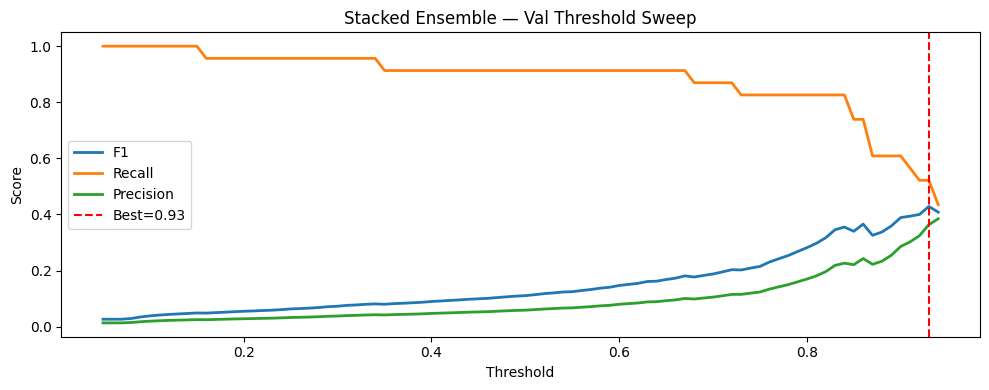

In [30]:
thresholds = np.arange(0.05, 0.95, 0.01)
results = []
for t in thresholds:
    p = (meta_val_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'f1':  f1_score(y_val, p, zero_division=0),
        'rec': recall_score(y_val, p, zero_division=0),
        'pre': precision_score(y_val, p, zero_division=0),
        'n_flagged': p.sum()
    })

res_df = pd.DataFrame(results)
best   = res_df.loc[res_df['f1'].idxmax()]
BEST_THRESHOLD = best['threshold']

print(f'Best threshold: {BEST_THRESHOLD:.2f}')
print(f'  F1={best["f1"]:.3f}  Recall={best["rec"]:.3f}  '
      f'Precision={best["pre"]:.3f}  Flagged={int(best["n_flagged"])}')

# Also show the top-5 threshold options
print('\nTop 5 F1 thresholds:')
print(res_df.nlargest(5, 'f1').to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(res_df['threshold'], res_df['f1'],  label='F1', lw=2)
ax.plot(res_df['threshold'], res_df['rec'], label='Recall', lw=2)
ax.plot(res_df['threshold'], res_df['pre'], label='Precision', lw=2)
ax.axvline(BEST_THRESHOLD, color='red', ls='--', label=f'Best={BEST_THRESHOLD:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Stacked Ensemble — Val Threshold Sweep')
ax.legend(); plt.tight_layout(); plt.show()

## Cell 13 — Validation report + per-outcome analysis

=== STACKED ENSEMBLE — VAL ===
              precision    recall  f1-score   support

   no_ticket       0.99      0.99      0.99      1692
      ticket       0.36      0.52      0.43        23

    accuracy                           0.98      1715
   macro avg       0.68      0.75      0.71      1715
weighted avg       0.99      0.98      0.98      1715



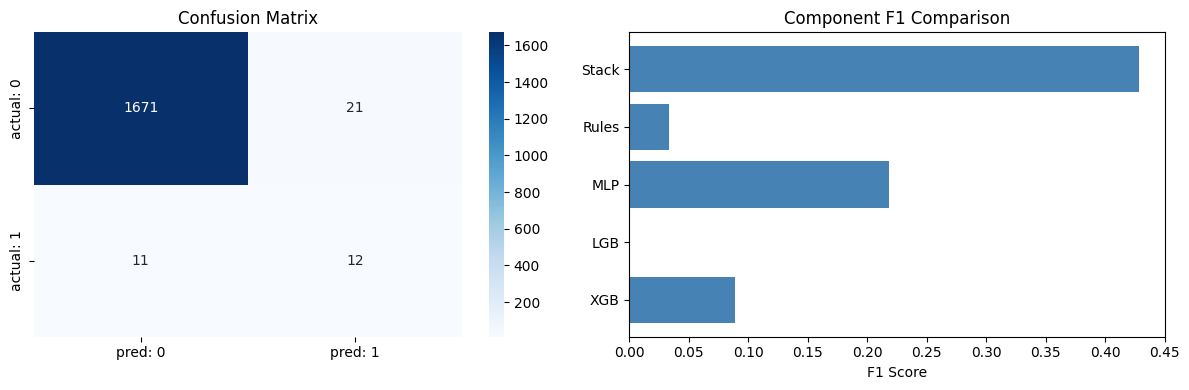


Per-outcome breakdown (KEY metric):
                       total  actual_tickets  pred_tickets  correct_flags  false_positives
outcome                                                                                   
completed                443               8            12              6                6
escalated                194               1             1              1                0
incomplete               340              10            17              3               14
opted_out                436               1             1              1                0
opted_to_fill_via_web      8               0             0              0                0
scheduled                278               1             0              0                0
voicemail                  1               1             0              0                0
wrong_number              15               1             2              1                1


In [31]:
val_preds = (meta_val_proba >= BEST_THRESHOLD).astype(int)

print('=== STACKED ENSEMBLE — VAL ===')
print(classification_report(y_val, val_preds, target_names=['no_ticket','ticket']))

cm = confusion_matrix(y_val, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['pred: 0','pred: 1'],
            yticklabels=['actual: 0','actual: 1'])
axes[0].set_title('Confusion Matrix')

# Component comparison
comp = pd.DataFrame({
    'Model': ['XGB','LGB','MLP','Rules','Stack'],
    'F1':    [
        f1_score(y_val, (xgb_model.predict_proba(X_val)[:,1]>=0.4).astype(int), zero_division=0),
        f1_score(y_val, (lgb_model.predict_proba(X_val)[:,1]>=0.4).astype(int), zero_division=0),
        f1_score(y_val, (mlp_val_proba>=0.4).astype(int), zero_division=0),
        f1_score(y_val, (val_rule_score>=0.4).astype(int), zero_division=0),
        f1_score(y_val, val_preds, zero_division=0)
    ]
})
axes[1].barh(comp['Model'], comp['F1'], color='steelblue')
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Component F1 Comparison')
plt.tight_layout(); plt.show()

# Per-outcome breakdown
val_eval = val_df.copy()
val_eval['pred']   = val_preds
val_eval['actual'] = y_val.values
print('\nPer-outcome breakdown (KEY metric):')
out_tbl = val_eval.groupby('outcome').apply(
    lambda g: pd.Series({
        'total':          len(g),
        'actual_tickets': g['actual'].sum(),
        'pred_tickets':   g['pred'].sum(),
        'correct_flags':  ((g['actual']==1)&(g['pred']==1)).sum(),
        'false_positives':((g['actual']==0)&(g['pred']==1)).sum()
    })
)
print(out_tbl.to_string())

## Cell 14 — SHAP

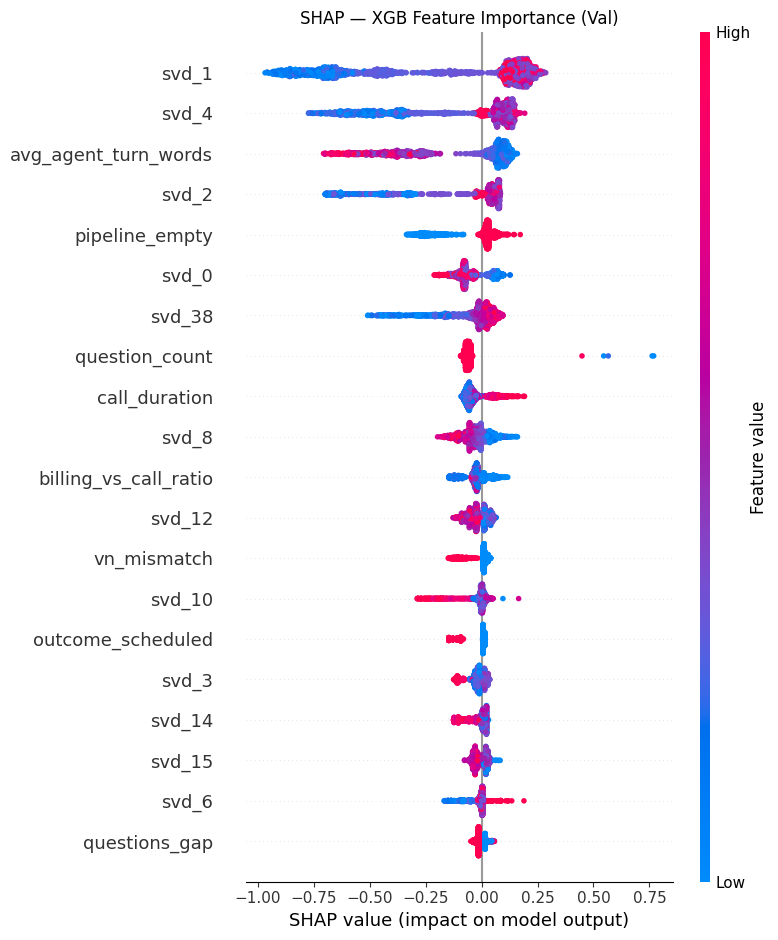

In [32]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val, max_display=20, show=False)
plt.title('SHAP — XGB Feature Importance (Val)')
plt.tight_layout(); plt.show()

## Cell 15 — Retrain on all labeled data

In [33]:
X_all  = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_all  = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
all_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
spw_all = (y_all==0).sum() / max((y_all==1).sum(), 1)

# Final XGB
final_xgb = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration+1, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=5,
    gamma=0.3, reg_alpha=0.5, reg_lambda=2.0,
    scale_pos_weight=spw_all, eval_metric='aucpr',
    random_state=SEED, use_label_encoder=False
)
final_xgb.fit(X_all, y_all, verbose=False)
print('Final XGB trained.')

# Final LGB
final_lgb = lgb.LGBMClassifier(
    n_estimators=lgb_model.best_iteration_+1, max_depth=5, learning_rate=0.03,
    num_leaves=31, subsample=0.8, colsample_bytree=0.7,
    min_child_samples=15, reg_alpha=0.5, reg_lambda=2.0,
    scale_pos_weight=spw_all, random_state=SEED, verbose=-1
)
final_lgb.fit(X_all, y_all)
print('Final LGB trained.')

# Final MLP (short training on all data)
print('Training final MLP...')
final_mlp_predict, _ = train_mlp(
    X_all.values, y_all, X_val.values, y_val,
    pos_weight=spw_all, n_epochs=60, device=device
)

# Rule scores on all data
all_X_struct = engineer_features(all_df)
all_rule_score = compute_rule_score(all_df, all_X_struct)

# Refit meta scaler + LR on all labeled data
all_xgb_p = final_xgb.predict_proba(X_all)[:, 1]
all_lgb_p = final_lgb.predict_proba(X_all)[:, 1]
all_mlp_p = final_mlp_predict(X_all.values)

meta_all_raw = np.column_stack([all_xgb_p, all_lgb_p, all_mlp_p, all_rule_score.values])
final_meta_scaler = StandardScaler()
meta_all_scaled   = final_meta_scaler.fit_transform(meta_all_raw)

final_meta = LogisticRegression(C=0.1, class_weight='balanced',
                                 max_iter=1000, random_state=SEED)
final_meta.fit(meta_all_scaled, y_all)
print(f'Final meta trained on {len(X_all)} samples.')

Final XGB trained.
Final LGB trained.
Training final MLP...
  Epoch  20: best F1=0.519
  Epoch  40: best F1=0.611
  Early stop @ epoch 57
Final meta trained on 9744 samples.


## Cell 16 — Test predictions

In [34]:
test_rule_score = compute_rule_score(test_df, X_test)

test_xgb_p = final_xgb.predict_proba(X_test)[:, 1]
test_lgb_p = final_lgb.predict_proba(X_test)[:, 1]
test_mlp_p = final_mlp_predict(X_test.values)

meta_test_raw    = np.column_stack([test_xgb_p, test_lgb_p, test_mlp_p, test_rule_score.values])
meta_test_scaled = final_meta_scaler.transform(meta_test_raw)
test_meta_proba  = final_meta.predict_proba(meta_test_scaled)[:, 1]

test_preds = (test_meta_proba >= BEST_THRESHOLD).astype(int)

submission = pd.DataFrame({
    'call_id':          test_df['call_id'],
    'predicted_ticket': test_preds.astype(bool)
})

print(f'Flagged: {test_preds.sum()} / {len(test_preds)} ({test_preds.mean():.1%})')
print('\nOutcome distribution among flagged:')
print(test_df.assign(pred=test_preds).groupby('outcome')['pred'].agg(['sum','count','mean'])
      .rename(columns={'sum':'flagged','count':'total','mean':'rate'}))

submission.to_csv('submission.csv', index=False)
print('\nSaved → submission.csv')

Flagged: 46 / 1736 (2.6%)

Outcome distribution among flagged:
                       flagged  total      rate
outcome                                        
completed                   24    447  0.053691
escalated                    1    198  0.005051
incomplete                  16    344  0.046512
opted_out                    2    438  0.004566
opted_to_fill_via_web        1      9  0.111111
scheduled                    0    281  0.000000
voicemail                    1      1  1.000000
wrong_number                 1     18  0.055556

Saved → submission.csv


## Cell 17 — Category prediction (bonus)

In [35]:
CAT_LABEL_MAP = {
    'ticket_cat_audio_issue':   'audio_issue',
    'ticket_cat_elevenlabs':    'elevenlabs',
    'ticket_cat_openai':        'openai',
    'ticket_cat_supabase':      'supabase',
    'ticket_cat_scheduler_aws': 'scheduler_aws',
    'ticket_cat_other':         'other'
}

def get_ticket_category(row):
    for col, label in CAT_LABEL_MAP.items():
        if col in row.index:
            val = str(row.get(col, '')).strip().lower()
            if val in ('true', '1', 'issue', 'yes'):
                return label
    return 'other' if row.get('has_ticket', False) else 'no_issue'


def rule_category(row_feat, row_data):
    """Infer category from signal features — ordered by specificity."""
    if row_feat.get('tr_audio', 0):                  return 'audio_issue'
    if row_feat.get('tr_frustration', 0):             return 'scheduler_aws'
    if row_feat.get('pipeline_mismatch_count', 0)>=3: return 'openai'
    if row_feat.get('qa_suspicious_weight', 0):       return 'openai'
    if row_feat.get('vn_fabricated', 0):              return 'openai'
    if row_feat.get('tr_medical', 0):                 return 'elevenlabs'
    if row_feat.get('hospital_not_escalated', 0):     return 'elevenlabs'
    if row_feat.get('completed_low_completeness', 0): return 'elevenlabs'
    if row_feat.get('review_flag', 0):                return 'openai'
    return 'other'


# Derive labels from train+val for category model
all_cat_labels = all_df.apply(get_ticket_category, axis=1)
ticket_mask    = all_cat_labels != 'no_issue'
X_cat          = X_all[ticket_mask.values]
y_cat_raw      = all_cat_labels[ticket_mask.values]

print('Category distribution:')
print(all_cat_labels.value_counts())

le = LabelEncoder()
y_cat = le.fit_transform(y_cat_raw)

USE_CAT_MODEL = len(le.classes_) > 1 and X_cat.shape[0] >= 10
if USE_CAT_MODEL:
    n_cls = len(le.classes_)
    cat_model = xgb.XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1,
        subsample=0.8,
        objective='multi:softprob' if n_cls > 2 else 'binary:logistic',
        num_class=n_cls if n_cls > 2 else None,
        eval_metric='mlogloss' if n_cls > 2 else 'logloss',
        random_state=SEED, use_label_encoder=False
    )
    cat_model.fit(X_cat, y_cat, verbose=False)
    print(f'Category model trained ({n_cls} classes).')
else:
    print('Using rule-based category fallback.')

# Generate categories for flagged test rows
flagged = test_preds == 1
submission_cat = submission.copy()
submission_cat['ticket_category'] = 'no_issue'

if flagged.sum() > 0:
    if USE_CAT_MODEL:
        cat_preds  = cat_model.predict(X_test[flagged])
        cat_labels = le.inverse_transform(cat_preds)
        submission_cat.loc[flagged, 'ticket_category'] = cat_labels
    else:
        X_test_feat = X_test_s  # structured features (with interpretable columns)
        for idx in X_test[flagged].index:
            feat_row = X_test_feat.loc[idx].to_dict()
            data_row = test_df.loc[idx]
            submission_cat.loc[idx, 'ticket_category'] = rule_category(feat_row, data_row)

    # Hard override: audio signal → audio_issue
    audio_flagged = flagged & (X_test['tr_audio'] == 1)
    submission_cat.loc[audio_flagged, 'ticket_category'] = 'audio_issue'

print('\nCategory distribution among flagged:')
print(submission_cat[submission_cat['predicted_ticket']]['ticket_category'].value_counts())

submission[['call_id','predicted_ticket']].to_csv('submission.csv', index=False)
submission_cat[['call_id','predicted_ticket','ticket_category']].to_csv(
    'submission_with_categories.csv', index=False
)
print('\nSaved → submission.csv')
print('Saved → submission_with_categories.csv')

Category distribution:
no_issue       9604
other           133
elevenlabs        4
audio_issue       3
Name: count, dtype: int64
Category model trained (3 classes).

Category distribution among flagged:
ticket_category
other    46
Name: count, dtype: int64

Saved → submission.csv
Saved → submission_with_categories.csv


## Cell 18 — Download

In [36]:
from google.colab import files
files.download('submission.csv')
files.download('submission_with_categories.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Changelog v2 → v3

| Issue in v2 | Fix in v3 |
|---|---|
| Rules as hard override (0.03 precision) | Rules as weighted soft score (0–1), blended via meta-learner |
| MLP weight=10.8 (dominated ensemble) | StandardScaler on meta-features + C=0.1 L2 reg |
| MLP overfitting (train F1=1.0) | Dropout 0.5/0.4/0.3 + weight_decay=1e-3 + threshold sweep per epoch |
| SMOTE hurt precision | Removed SMOTE; use scale_pos_weight + class_weight throughout |
| XGB/LGB too deep | max_depth 5→4, stronger gamma/reg_alpha/reg_lambda |
| Meta-LR unscaled | StandardScaler on meta-features before LR fit |
| 84 false positives on completed | No hard rule override; threshold optimizes F1 directly |